Phase 1: Environment & Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Load Dataset (AI4I-PMDI 2024 Edition)
df = pd.read_csv('AI4I-PMDI.csv')
df.columns = df.columns.str.strip()

# 2. Expert Feature Engineering (ECM Perspective)
# Map product quality type to numeric
df['Type'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})

# Physics-based features: Thermal Stress and Power Index
df['Temp_Diff'] = df['Process temperature (K)'] - df['Air temperature (K)']
df['Power'] = df['Torque (Nm)'] * df['Rotational speed (rpm)']

# 3. Data Cleaning
# Drop non-predictive IDs and administrative columns
drop_cols = ['UDI', 'Date', 'System', 'Control', 'Product ID']
df_model = df.drop(drop_cols, axis=1)

# Separate Features and Target (Diagnostic is the label in 2024 version)
X = df_model.drop('Diagnostic', axis=1)
y = df_model['Diagnostic']

# Train-Test Split (Ensuring failure distribution remains consistent)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


/Users/wenpin/ML_Projects/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Phase 2: Imbalanced Data Handling & Training

In [2]:
# 1. Handling Missing Values (Median imputation for sensor robustness)
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 2. Address Class Imbalance via SMOTE
# Failures are rare (approx. 3%), SMOTE helps the model learn failure patterns
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_imputed, y_train)

# 3. Model Training: LightGBM Classifier
lgb_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42,
    importance_type='gain'
)
lgb_model.fit(X_train_res, y_train_res)

# 4. Evaluation
y_pred = lgb_model.predict(X_test_imputed)
y_prob = lgb_model.predict_proba(X_test_imputed)

print("--- Performance Report ---")
print(classification_report(y_test, y_pred))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001045 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2038
[LightGBM] [Info] Number of data points in the train set: 46332, number of used features: 8
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/Users/wenpin/ML_Projects/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/wenpin/ML_Projects/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- Performance Report ---
                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      1.00      1.00        21
              No failure       1.00      0.98      0.99      1930
      Overstrain Failure       0.95      1.00      0.98        20
           Power Failure       1.00      1.00      1.00        17
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.28      0.62      0.38         8

                accuracy                           0.98      2000
               macro avg       0.70      0.77      0.72      2000
            weighted avg       0.99      0.98      0.98      2000



Phase 3: Explainable AI (SHAP Analysis)

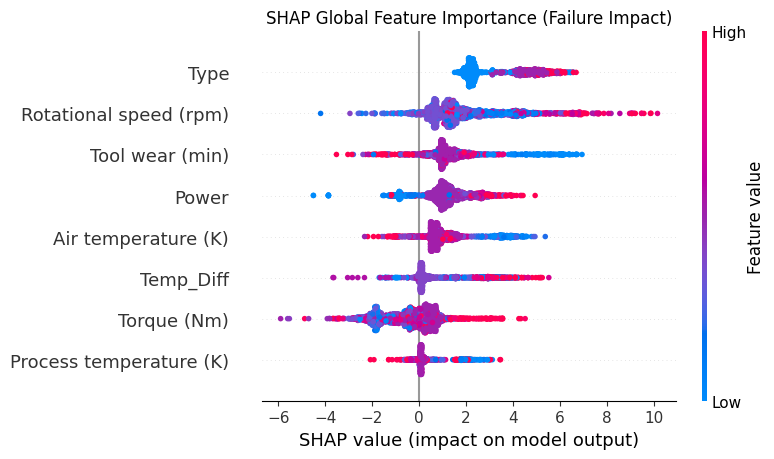

✅ Success: Visualizing Case Index: 0
✅ Actual Diagnosis: Power Failure


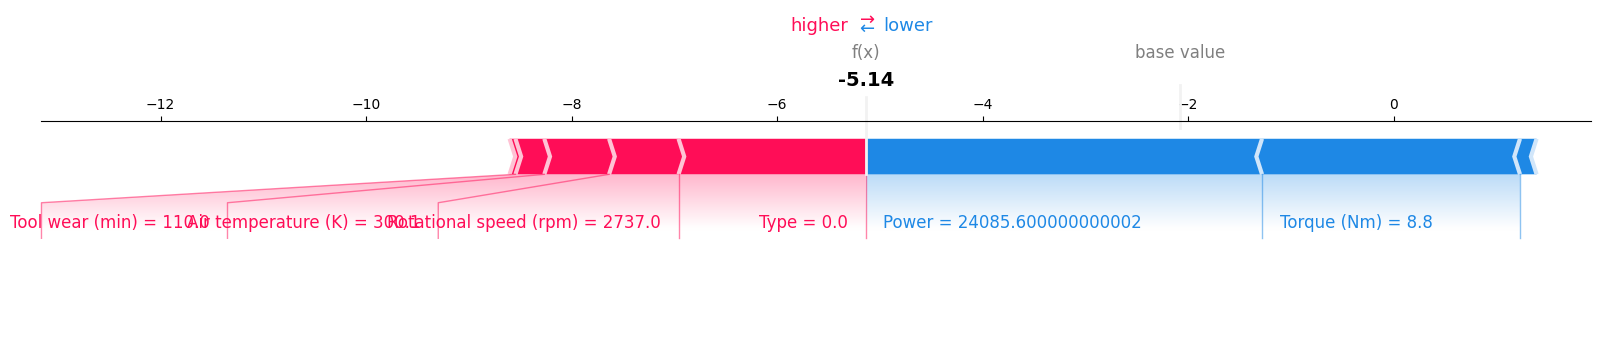

In [3]:
# --- 1. Initialize SHAP Explainer ---
X_test_df = pd.DataFrame(X_test_imputed, columns=X.columns)
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test_df)

# --- 2. Global Interpretation: Summary Plot ---
plt.figure(figsize=(10, 6))

if isinstance(shap_values, list):
    # For Multi-class, visualize the impact on the first failure class
    shap.summary_plot(shap_values, X_test_df, show=False)
elif len(shap_values.shape) == 3:
    shap.summary_plot(shap_values[:, :, 1], X_test_df, show=False)
else:
    shap.summary_plot(shap_values, X_test_df, show=False)

plt.title("SHAP Global Feature Importance (Failure Impact)")
plt.tight_layout()
plt.show()

# --- 3. Local Interpretation: Force Plot ---
shap.initjs()

# Locate the first failure sample
fail_indices = np.where(y_test.values != 'No failure')[0]

if len(fail_indices) > 0:
    target_idx = fail_indices[0] # Get the first integer index
    actual_diagnosis = y_test.values[target_idx]
    
    print(f"✅ Success: Visualizing Case Index: {target_idx}")
    print(f"✅ Actual Diagnosis: {actual_diagnosis}")
    
    # Handle base_value (expected_value) and shap_values specifically for Multi-class
    if isinstance(shap_values, list):
        # Case: List of arrays (one per class)
        sv = shap_values[target_idx]
        ev = explainer.expected_value # If this fails, try explainer.expected_value[1]
    elif len(shap_values.shape) == 3:
        # Case: 3D array (samples, features, classes)
        sv = shap_values[target_idx, :, 1]
        ev = explainer.expected_value if not isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value[1]
    else:
        # Case: Standard 2D array
        sv = shap_values[target_idx]
        ev = explainer.expected_value

    # Explicitly pass parameters to avoid TypeError
    shap.force_plot(
        ev,             # Base value (The first parameter!)
        sv,             # SHAP values
        X_test_df.iloc[target_idx, :],
        matplotlib=True 
    )
else:
    print("⚠️ Warning: No failure samples found.")
